In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Ensure output dir exists
out_dir = Path('../outputs/visualizations')
out_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Cell: Compare Model Performance
def plot_training_history(histories, model_names):
    """Plot training histories for multiple models"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    metrics = ['train_loss', 'val_loss', 'val_rmse', 'val_mae', 'val_r2', 'val_nasa_score']
    titles = ['Training Loss', 'Validation Loss', 'Validation RMSE', 
              'Validation MAE', 'Validation R²', 'Validation NASA Score']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        row = idx // 3
        col = idx % 3
        
        for history, name in zip(histories, model_names):
            axes[row, col].plot(history[metric], label=name, linewidth=2)
        
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel(title)
        axes[row, col].set_title(title)
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/visualizations/training_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
try:
    with open("../outputs/saved_models/results_all.pkl", "rb") as results_file:
        results = pickle.load(results_file)
        print("Results Loaded....")
except Exception as e:
    print(f"ERROR: {e}")

Results Loaded....


In [5]:
results.keys()

dict_keys(['LSTM', 'GRU', 'CNNLSTM', 'Transformer'])

In [6]:
results['LSTM']['history'].keys()

dict_keys(['train_loss', 'val_loss', 'val_rmse', 'val_mae', 'val_r2', 'val_nasa_score', 'learning_rate'])

In [7]:
lstm_history = results['LSTM']['history']
gru_history = results['GRU']['history']
cnn_lstm_history = results['CNNLSTM']['history']
transformer_history = results['Transformer']['history']

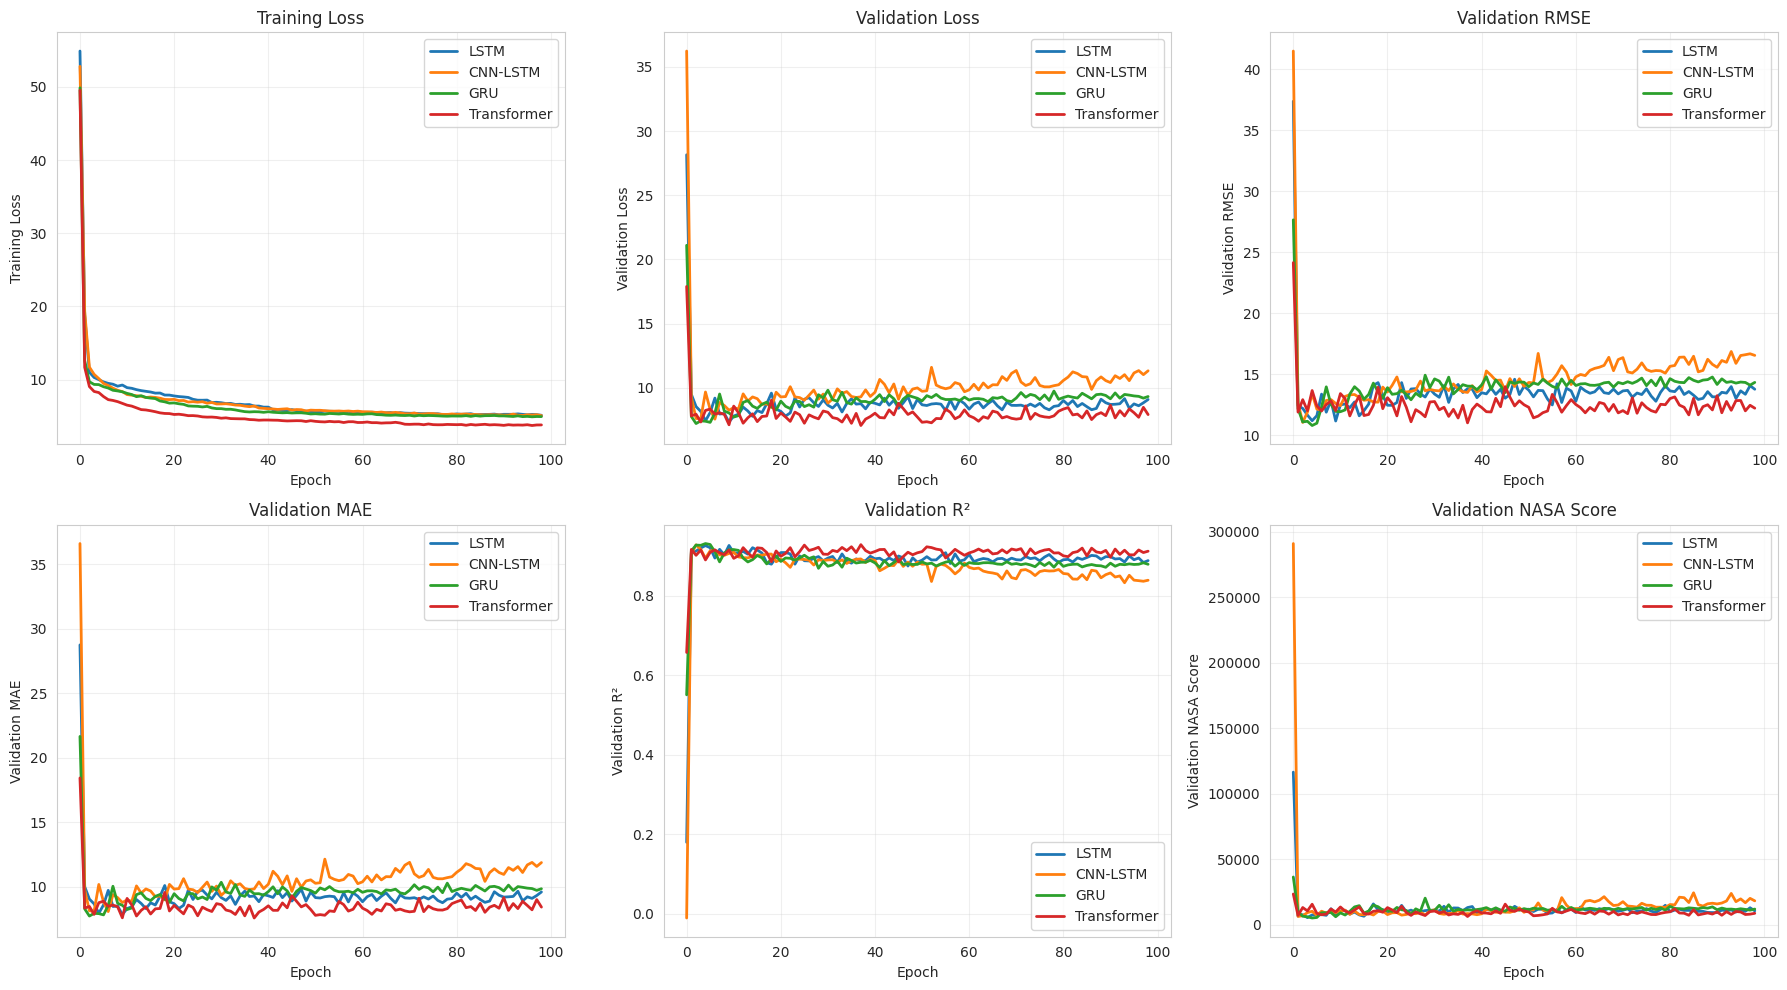

In [8]:
# Plot comparison
histories = [lstm_history, cnn_lstm_history, gru_history, transformer_history]
model_names = ['LSTM', 'CNN-LSTM', 'GRU', 'Transformer']

plot_training_history(histories, model_names)

In [9]:
results['LSTM']['test_metrics'][0]

{'mse': 295.5052490234375,
 'rmse': 17.190266112641698,
 'mae': 12.244132041931152,
 'r2': 0.8288780450820923,
 'nasa_score': 586.289306640625,
 'loss': 11.557664632797241}

In [10]:
eval_results = []
for model_name in results.keys():
    #print(model_name)
    metrics = results[model_name]['test_metrics'][0]

    eval_results.append({
            'Model': model_name,
            'MSE' : metrics['mse'],
            'RMSE': metrics['rmse'],
            'MAE': metrics['mae'],
            'R²': metrics['r2'],
            'NASA_Score': metrics['nasa_score'],
            'Loss': metrics['loss']
        })
    
    print(f"\n{model_name} Results:")
    print(f"  MSE : {metrics['mse']:.4f}")
    print(f"  RMSE: {metrics['rmse']:.4f}")
    print(f"  MAE: {metrics['mae']:.4f}")
    print(f"  R²: {metrics['r2']:.4f}")
    print(f"  NASA Score: {metrics['nasa_score']:.2f}")

    eval_results_df = pd.DataFrame(eval_results)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(eval_results_df.to_string(index=False))


LSTM Results:
  MSE : 295.5052
  RMSE: 17.1903
  MAE: 12.2441
  R²: 0.8289
  NASA Score: 586.29

GRU Results:
  MSE : 239.2681
  RMSE: 15.4683
  MAE: 11.2289
  R²: 0.8614
  NASA Score: 425.76

CNNLSTM Results:
  MSE : 271.1425
  RMSE: 16.4664
  MAE: 12.3205
  R²: 0.8430
  NASA Score: 494.99

Transformer Results:
  MSE : 259.2484
  RMSE: 16.1012
  MAE: 11.8681
  R²: 0.8499
  NASA Score: 528.10

MODEL COMPARISON
      Model        MSE      RMSE       MAE       R²  NASA_Score      Loss
       LSTM 295.505249 17.190266 12.244132 0.828878  586.289307 11.557665
        GRU 239.268066 15.468292 11.228937 0.861444  425.759064 10.103199
    CNNLSTM 271.142456 16.466404 12.320481 0.842986  494.991180 12.437735
Transformer 259.248383 16.101192 11.868095 0.849874  528.099915 13.056251


In [11]:
import torch

In [12]:
def plot_predictions(model, test_loader, device, model_name, num_samples=50):
    """Plot predictions vs actual values"""
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data).squeeze()
            predictions.extend(output.cpu().numpy())
            actuals.extend(target.cpu().numpy())
    
    predictions = np.array(predictions)[:num_samples]
    actuals = np.array(actuals)[:num_samples]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Predictions vs Actuals
    axes[0].scatter(actuals, predictions, alpha=0.6, s=50)
    axes[0].plot([actuals.min(), actuals.max()], 
                 [actuals.min(), actuals.max()], 
                 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual RUL')
    axes[0].set_ylabel('Predicted RUL')
    axes[0].set_title(f'{model_name}: Predictions vs Actual')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Error distribution
    errors = predictions - actuals
    axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[1].set_xlabel('Prediction Error')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{model_name}: Error Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/visualizations/{model_name.lower()}_predictions.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
